# **MPO Power Bootstrap Demo**

In [1]:
include("normalized_powers.jl")
using ITensors
using ITensorMPS
using LinearAlgebra


$$
H = -J \sum_i Z_i Z_{i+1} - g \sum_i X_i
$$
We use TFIM with small size and use DMRG to check the ground energy first.


In [3]:
L = 7
J = 1.0
g = 1.0

H = TFIM(L; J=J, g=g, periodic=true)

sites = firstsiteinds(H)

psi0 = random_mps(sites; linkdims=2)

energy, psi = dmrg(H, psi0; nsweeps=8,  cutoff=1e-12)

println("DMRG energy: ", energy)


After sweep 1 energy=-8.935642180272998  maxlinkdim=8 maxerr=0.00E+00 time=5.886
After sweep 2 energy=-8.987351837713724  maxlinkdim=8 maxerr=0.00E+00 time=0.002
After sweep 3 energy=-8.987915916318727  maxlinkdim=8 maxerr=0.00E+00 time=0.011
After sweep 4 energy=-8.987918401977444  maxlinkdim=8 maxerr=0.00E+00 time=0.002
After sweep 5 energy=-8.987918414768396  maxlinkdim=8 maxerr=0.00E+00 time=0.002
After sweep 6 energy=-8.98791841486948  maxlinkdim=8 maxerr=0.00E+00 time=0.002
After sweep 7 energy=-8.987918414869878  maxlinkdim=8 maxerr=0.00E+00 time=0.002
After sweep 8 energy=-8.987918414869865  maxlinkdim=8 maxerr=0.00E+00 time=0.001
DMRG energy: -8.987918414869865


# 1. OPE tensor: approximate vs exact


- `ope_tensor(H, n)`:
  1. builds normalized powers `B[1:2n]` using `krylov_basis`
  2. computes the Gram matrix `T[p,q] = Tr(B[p]† B[q])`
  3. uses the approximation
     $$
     B_i B_j \approx \alpha_{ij} B_q, \quad q=i+j-1
     $$
     where `α_ij` is taken from `norm_list[i,j] ≈ ‖comp(B[i]B[j])‖` or using log scale norms $log(||H^k||)$
  4. then sets
     $$
     A_{ij k} \approx \alpha_{ij} \; T_{qk}
     $$

- `ope_tensor_exact(H, n)`:  explicitly multiplies the cheapest adjacent pair among `(i,j)`, `(j,k)`, `(k,i)` ,
  then take inner product with the remaining operator to get
  $$
  A_{ijk} = Tr(B_i B_j B_k)
  $$

`ope_tensor_exact(H, n)` takes MPO multiplication for every pair of basis, so it takes significantly more time to compute.


We use `Aapprox - Aexact` to measure how good the product-closure approximation is at the chosen truncation settings.

In [4]:
function compare_ope_tensors(
  H::MPO,
  n::Integer;
  cutoff::Float64 = 1e-12,
  maxdim::Int = 256,
  truncate::Bool = true,
  verbose::Bool = false,
)
  Aapprox = ope_tensor(
    H, n;
    cutoff=cutoff, maxdim=maxdim, truncate=truncate,
    verbose=verbose, return_aux=false
  )

  Aexact = ope_tensor_exact(
    H, n;
    cutoff=cutoff, maxdim=maxdim, truncate=false,
    verbose=verbose, return_aux=false
  )

  diff = Aapprox .- Aexact
  frob = norm(diff)
  frob_exact = norm(Aexact)
  max_abs = maximum(abs.(diff))


  report = (
    frobenius = frob,
    frobenius_exact_ope = frob_exact,
    max_abs = max_abs,
    cutoff = cutoff,
    maxdim = maxdim,
    truncate = truncate,
  )

  return Aapprox, Aexact, report
end


compare_ope_tensors (generic function with 1 method)

In [5]:
n = 8 

Aapprox, Aexact, report = compare_ope_tensors(
  H, n;
  cutoff=1e-12,
  maxdim=256,
  truncate=true,   
  verbose=true
)

println(report)


B[ 3] ~ H^ 2 (square): maxbond=8
B[ 4] ~ H^ 3 (block base=2,r=1): maxbond=14
B[ 5] ~ H^ 4 (square): maxbond=24
B[ 6] ~ H^ 5 (block base=4,r=1): maxbond=35
B[ 7] ~ H^ 6 (block base=4,r=2): maxbond=46
B[ 8] ~ H^ 7 (block base=4,r=3): maxbond=59
B[ 9] ~ H^ 8 (square): maxbond=60
B[10] ~ H^ 9 (block base=8,r=1): maxbond=62
B[11] ~ H^10 (block base=8,r=2): maxbond=62
B[12] ~ H^11 (block base=8,r=3): maxbond=64
B[13] ~ H^12 (block base=8,r=4): maxbond=64
B[14] ~ H^13 (block base=8,r=5): maxbond=64
B[15] ~ H^14 (block base=8,r=6): maxbond=64
B[16] ~ H^15 (block base=8,r=7): maxbond=64
OPE Row Finished i = 1 / 8
OPE Row Finished i = 2 / 8
OPE Row Finished i = 3 / 8
OPE Row Finished i = 4 / 8
OPE Row Finished i = 5 / 8
OPE Row Finished i = 6 / 8
OPE Row Finished i = 7 / 8
OPE Row Finished i = 8 / 8
Exact OPE Row Finished i = 1 / 8
Exact OPE Row Finished i = 2 / 8
Exact OPE Row Finished i = 3 / 8
Exact OPE Row Finished i = 4 / 8
Exact OPE Row Finished i = 5 / 8
Exact OPE Row Finished i = 6 / 8
E

* frobenius exact is the the frobenius norm of exact ope, and measure how small the difference between exact and approx ope is relative to it. Similarly max compares the element with maximum norm values.

#  2. Energy sweep and numerical stability diagnostics

The `bootstrap` function returns
- `E`: objective value (energy estimate)
- `λmin`: smallest eigenvalue of the **evaluated** moment matrix $M(x_{opt})= \sum x_{opt, i} A_i$
- `status`: solver termination status


In [6]:

function energy_sweep(H::MPO, n_range::AbstractVector{Int})
  energies = Float64[]
    lambdas = Float64[]

  println("\n==========================")
  println("Starting Energy Sweep")
  println("n range: $n_range")
  println("==========================\n")

  for n_val in n_range
    
    res = bootstrap(
      H,
      n_val;
      verbose_ope=false,
      cutoff=1e-12,
      maxdim=256,
      truncate=true,
      silent=true 
    )
    
    push!(energies, res.E)
    push!(lambdas, res.λmin)
    println("  -> n = $n_val, Energy = $(res.E), lambda_min = $(res.λmin), Status = $(res.status)")
  end

  return n_range, energies, lambdas
end

ns, Es, lmins = energy_sweep(H, 4:12)


Starting Energy Sweep
n range: 4:12

  -> n = 4, Energy = -54.26717447132298, lambda_min = 2.550422083396959e-7, Status = ALMOST_OPTIMAL
  -> n = 5, Energy = -21.91888634136926, lambda_min = 2.756543734333636e-8, Status = ALMOST_OPTIMAL
  -> n = 6, Energy = -14.348190095804906, lambda_min = -9.895139704485155e-6, Status = ALMOST_OPTIMAL
  -> n = 7, Energy = -10.752235205010015, lambda_min = -1.1620494887208515e-7, Status = ALMOST_OPTIMAL
  -> n = 8, Energy = -8.982467883225647, lambda_min = -4.779597726064238e-7, Status = ALMOST_OPTIMAL
  -> n = 9, Energy = -8.974273819591023, lambda_min = -9.56710113789043e-5, Status = NUMERICAL_ERROR
  -> n = 10, Energy = -8.935638120868871, lambda_min = -0.00011405685404126371, Status = SLOW_PROGRESS
  -> n = 11, Energy = -8.9343199443376, lambda_min = -0.00011780623724781588, Status = NUMERICAL_ERROR
  -> n = 12, Energy = -8.737514140561808, lambda_min = -0.000394802299045313, Status = SLOW_PROGRESS


(4:12, [-54.26717447132298, -21.91888634136926, -14.348190095804906, -10.752235205010015, -8.982467883225647, -8.974273819591023, -8.935638120868871, -8.9343199443376, -8.737514140561808], [2.550422083396959e-7, 2.756543734333636e-8, -9.895139704485155e-6, -1.1620494887208515e-7, -4.779597726064238e-7, -9.56710113789043e-5, -0.00011405685404126371, -0.00011780623724781588, -0.000394802299045313])

## Energy Plot



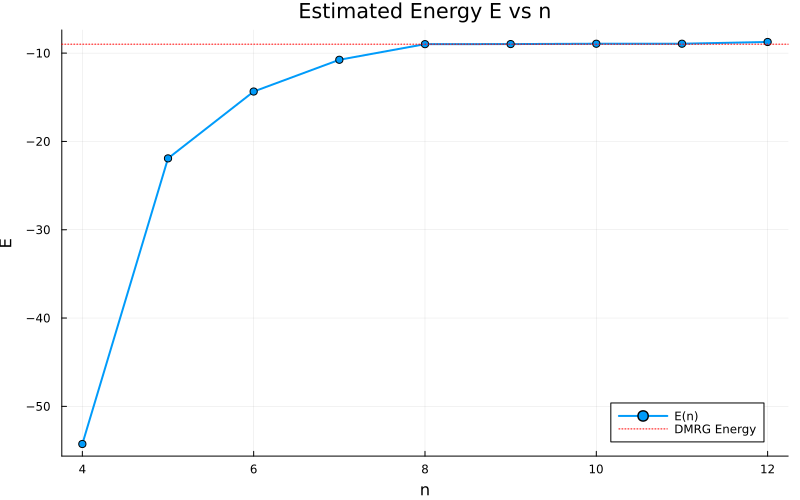

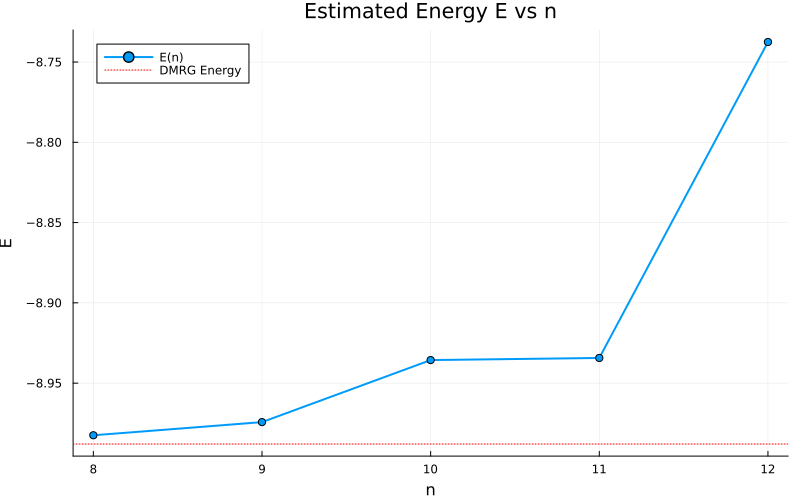

In [7]:
using Plots

function plot_sweep(ns, Es, ref_E)
    
    # This visualizes the magnitude of the negative energy logarithmically.
    p = plot(ns, Es, 
          marker=:circle, 
          title="Estimated Energy E vs n",
          xlabel="n", 
          ylabel="E",
          label="E(n)",
          lw=2,
          size=(800, 500))
    
    hline!(p, [ref_E], linestyle=:dot, color=:red, label="DMRG Energy")
        
    display(p)
end

plot_sweep(ns, Es, energy)
plot_sweep(ns[5:end], Es[5:end], energy) 


Here we see that E(n) converges from below when n is small, but after 8th krylov iteration, we get a jump that goes above the exact value. While truncation and ope being approximated can cause this,  SDP we impose is simply numerical ill.

## Compare λmin to solver tolerances

`λmin`: smallest eigenvalue of the **evaluated** moment matrix $M(x_{opt})= \sum x_{opt, i} A_i$

Numerically, solvers can return a point where PSD is satisfied only up to tolerance.
We compute `λmin(M(x))` to check whether

- `λmin ≥ 0` : PSD satisfied (up to roundoff)
- small negative (e.g. `-1e-8`) : typically within solver feasibility tolerance
- large negative : real PSD violation (bad model data / ill-conditioning / solver did not converge)

In the `bootstrap`, we set Clarabel tolerances:

- `tol_feas` = 1e-12
- `tol_gap_abs`, `tol_gap_rel` = 1e-12

If `|λmin|` is on the order of `tol_feas` (or maybe 10–100× larger), that’s usually just numerical slack.
If `|λmin|` is **many orders of magnitude larger**, you are no longer solving the intended SDP accurately.


In [73]:
tol_feas = 1e-12  

for (n, λ) in zip(ns, lmins)
  ratio = abs(λ) / tol_feas
  @printf("n=%2d  λmin=%+.3e  |λmin|/tol_feas=%.2e  \n", n, λ, ratio)
end

n= 2  λmin=-5.661e-01  |λmin|/tol_feas=5.66e+11  
n= 3  λmin=+4.338e-06  |λmin|/tol_feas=4.34e+06  
n= 4  λmin=+2.550e-07  |λmin|/tol_feas=2.55e+05  
n= 5  λmin=+2.757e-08  |λmin|/tol_feas=2.76e+04  
n= 6  λmin=-9.895e-06  |λmin|/tol_feas=9.90e+06  
n= 7  λmin=-1.162e-07  |λmin|/tol_feas=1.16e+05  
n= 8  λmin=-4.780e-07  |λmin|/tol_feas=4.78e+05  
n= 9  λmin=-9.567e-05  |λmin|/tol_feas=9.57e+07  
n=10  λmin=-1.141e-04  |λmin|/tol_feas=1.14e+08  
n=11  λmin=-1.178e-04  |λmin|/tol_feas=1.18e+08  
n=12  λmin=-3.948e-04  |λmin|/tol_feas=3.95e+08  


Since we are dealing with small scale SDP, we use Jump Clarabel which uses interior point method with fewer iterations. SLOW_PROGRESS / INSUFFICIENT_PROGRESS indicates the problem is:
- ill-conditioned (nearly singular PSD matrices)
- inconsistent due to approximation errors (A tensor not “self-consistent” with true products)
- too tight tolerances for the conditioning level

The |λmin| increases as we increase the n, which shows that higher order basis imposes infeasible problem. I further address the reason below.


# 3. T matrix, higher-order bases, and linear dependence
 `pair_trace_matrix` returns:

$$
T_{ij} = Tr(B_i^\dagger B_j)
$$

Since we normalize each `B_i` to have `Tr(B_i^† B_i)=1`, the diagonal should be ≈1.

### Why normalized powers get linearly dependent 


Let `H` have eigenvalues $\lambda_r$.
Then (schematically, in an eigenbasis) entries of `H^p` scale like $\lambda_r^p$.

After normalizing by the Frobenius norm, for large `p` the operator
$H^p$ becomes dominated by the eigen-components with the largest $|\lambda_r|$.
So successive normalized powers become nearly collinear in operator space.

This shows up as:
- `|T[i,j]| → 1` for many pairs (high correlation)
- very small eigenvalues of `T` (near rank-deficiency)
- huge condition numbers `cond(T)` (ill-conditioning)



## Compute Gram diagnostics vs basis size

For each `n`, we build `B[1:2n]` and its Gram matrix `T`, then compute:

- `min_eig(T)` (smallest eigenvalue)
- `cond(T)` (condition number)
- `max_offdiag(T)` (largest absolute off-diagonal entry)



In [9]:
function gram_diagnostics(H::MPO, n::Int; cutoff=1e-12, maxdim=256, truncate=true)
  B, trB, Id, Ts, norm_list, log_pow_norm, h_scale = krylov_basis(
    H, n;
    cutoff=cutoff, maxdim=maxdim, truncate=truncate,
    verbose=false, return_aux=true
  )


  eigs = eigvals(Symmetric(Ts))
  mine = minimum(eigs)
  maxe = maximum(eigs)

  # Avoid cond() failing if it is exactly singular numerically:
  cnd = maxe / max(mine, eps(Float64))

  m = size(Ts, 1)
  max_off = 0.0
  for i in 1:m, j in 1:m
    if i != j
      max_off = max(max_off, abs(Ts[i,j]))
    end
  end

  return (T=Ts, mineig=mine, maxeig=maxe, cond=cnd, max_offdiag=max_off)
end

diags = Dict{Int,Any}()

for n in ns
  diags[n] = gram_diagnostics(H, n; cutoff=1e-12, maxdim=256, truncate=false)
  d = diags[n]
  @printf("n=%2d  span=%2d  minEig(T)=%.3e  cond(T)≈%.3e  max|offdiag|=%.3e
",
          n, 2n, d.mineig, d.cond, d.max_offdiag)
end


n= 4  span= 8  minEig(T)=4.811e-04  cond(T)≈7.361e+03  max|offdiag|=9.840e-01
n= 5  span=10  minEig(T)=1.612e-05  cond(T)≈2.835e+05  max|offdiag|=9.930e-01
n= 6  span=12  minEig(T)=7.389e-07  cond(T)≈7.755e+06  max|offdiag|=9.964e-01
n= 7  span=14  minEig(T)=1.132e-08  cond(T)≈6.173e+08  max|offdiag|=9.978e-01
n= 8  span=16  minEig(T)=1.848e-10  cond(T)≈4.507e+10  max|offdiag|=9.986e-01
n= 9  span=18  minEig(T)=3.969e-12  cond(T)≈2.451e+12  max|offdiag|=9.990e-01
n=10  span=20  minEig(T)=3.505e-14  cond(T)≈3.191e+14  max|offdiag|=9.992e-01
n=11  span=22  minEig(T)=-4.523e-16  cond(T)≈5.711e+16  max|offdiag|=9.994e-01
n=12  span=24  minEig(T)=-7.172e-16  cond(T)≈6.403e+16  max|offdiag|=9.995e-01



If there exists $\lambda_{min}$ that are very close to 0, then there exists  $x \in \R^{n} $ such that 
$$
\left\| \sum_i x_i B_i \right\|^2
= \sum_{i,j} x_i x_j \,\mathrm{Tr}(B_i^\dagger B_j)
= x^\top T x
\approx 0.
$$

Meaning that there is non-trivial direction in correlation function that barely changes the constraint matrix $M$

## Visualizing |T| as a heatmap 

If the basis is becoming collinear, large blocks of entries will become close to 1 in magnitude.


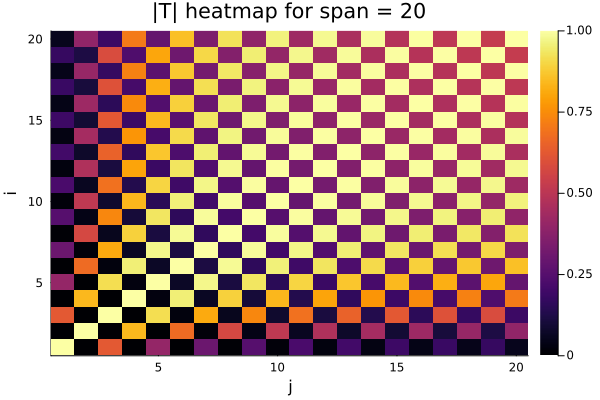

In [10]:
n_show = 10
Tshow = diags[n_show].T

heatmap(abs.(Tshow),
  title="|T| heatmap for span = $(2n_show)",
  xlabel="j", ylabel="i")


Interestingly, we see a checkerboard pattern in T for TFIM. Even/even, odd/odd pairs have lighter squares and even/odd pairs have darker square, which indicates that $H^{i+j}$ is closer to one of two major subspaces that are almost orthogonal, depending on even or odd $i+j$ is.

 Even/Odd pairs in upper right corner becomes more and more brigher as expected becoming more and more dependent of each other.

# How linear dependence hurts the SDP


1. The ansatz is $\rho = \sum_k x_k B_k$.
2. The SDP constraint uses the **moment matrix**
   $$
   M_{ab}(x) = Tr(\rho B_a B_b) = \sum_k x_k A_{abk}.
   $$
3. If the basis `{B_k}` is nearly linearly dependent, then different `x` vectors can correspond to **almost the same** operator $\rho$.
   That means the mapping `x ↦ M(x)` becomes ill-conditioned.


4. Interior-point solvers rely on solving linear systems involving these matrices; near singularity ⇒
   - large numerical errors,
   - slow progress / stalling,
   - slightly infeasible PSD constraints (negative `λmin`).
